# Customer Churn Prediction using Machine Learning

## Objective

The objective of this notebook is to build a machine learning model that predicts whether a customer is likely to churn based on their purchasing behaviour.

The RFM features created in the previous notebook are used as predictors. The target variable is the churn indicator, where:

- **0** = Active Customer
- **1** = Churned Customer

This notebook demonstrates the complete machine learning workflow, including data preparation, model training, evaluation, and interpretation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

In [3]:
rfm = pd.read_csv("../data/customer_rfm_analysis.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,Churn
0,12346.0,326,1,77183.60,1,1,5,115,Need Attention,1
1,12347.0,2,7,4310.00,5,5,5,555,VIP,0
2,12348.0,75,4,1797.24,2,4,4,244,At Risk,0
3,12349.0,19,1,1757.55,4,1,4,414,Potential Loyalist,0
4,12350.0,310,1,334.40,1,1,2,112,Need Attention,1


In [4]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   float64
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
 4   R_score     4338 non-null   int64  
 5   F_score     4338 non-null   int64  
 6   M_score     4338 non-null   int64  
 7   RFM_Score   4338 non-null   int64  
 8   Segment     4338 non-null   str    
 9   Churn       4338 non-null   int64  
dtypes: float64(2), int64(7), str(1)
memory usage: 339.0 KB


In [5]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Churn
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.00000,4338.00000,4338.00000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081,3.00000,3.00000,3.00000,333.000000,0.198248
std,1721.808492,100.014169,7.697998,8985.230220,1.41454,1.41454,1.41454,150.053221,0.398726
min,12346.000000,1.000000,1.000000,3.750000,1.00000,1.00000,1.00000,111.000000,0.000000
25%,13813.250000,18.000000,1.000000,306.482500,2.00000,2.00000,2.00000,221.000000,0.000000
50%,15299.500000,51.000000,2.000000,668.570000,3.00000,3.00000,3.00000,333.000000,0.000000
75%,16778.750000,142.000000,5.000000,1660.597500,4.00000,4.00000,4.00000,454.000000,0.000000
max,18287.000000,374.000000,209.000000,280206.020000,5.00000,5.00000,5.00000,555.000000,1.000000


### Observation

- The dataset is now at the customer level instead of the transaction level.
- Each customer has Recency, Frequency, Monetary values, RFM scores, a customer segment, and a churn label.
- These features should help the model learn which purchasing patterns are associated with customer churn.

## Feature Engineering

To improve the predictive power of the model, a new feature called **Average Order Value (AOV)** is created.

Average Order Value measures the average amount spent per purchase and is calculated as:

**Average Order Value = Monetary / Frequency**

This feature helps capture customer spending behaviour without introducing target leakage.

In [6]:
rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"]

In [7]:
rfm[["CustomerID",
     "Frequency",
     "Monetary",
     "AvgOrderValue"]].head()

,CustomerID,Frequency,Monetary,AvgOrderValue
0,12346.0,1,77183.60,77183.600000
1,12347.0,7,4310.00,615.714286
2,12348.0,4,1797.24,449.310000
3,12349.0,1,1757.55,1757.550000
4,12350.0,1,334.40,334.400000


### Observation

- Average Order Value shows the average amount spent by a customer in each order.
- Customers with a higher average order value are generally more valuable to the business.
- Combining this with RFM features provides a better understanding of customer purchasing behaviour.

In [8]:
X = rfm[['Frequency', 'Monetary', 'AvgOrderValue']]

y = rfm['Churn']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [10]:
print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (3470, 3)
Testing Data : (868, 3)


### Observation

- The dataset was split into **80% training data** and **20% testing data**.
- The training set contains **3,470 customers**, while the testing set contains **868 customers**.
- The training data will be used to build the churn prediction model, and the testing data will be used to evaluate its performance on unseen customers.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_lr = lr_model.predict(X_test_scaled)

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.79      1.00      0.88       685
           1       0.00      0.00      0.00       183

    accuracy                           0.79       868
   macro avg       0.39      0.50      0.44       868
weighted avg       0.62      0.79      0.70       868



/Users/kavya9415/myenv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kavya9415/myenv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kavya9415/myenv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Model Evaluation

The Logistic Regression model was evaluated using a classification report, which includes Precision, Recall, F1-score, and Accuracy.

Overall Accuracy: **79%**

Although the model achieved an accuracy of 79%, the classification report shows that it predicted only the majority class (Active Customers) and failed to correctly identify churned customers.

### Key Observations

- The model correctly classified most active customers.
- Precision, Recall, and F1-score for the churn class are all **0.00**.
- This indicates that the model did not predict any customer as churned.
- The dataset is imbalanced, with significantly more active customers than churned customers.
- As a result, the model became biased toward predicting the majority class.

### Conclusion

Accuracy alone is not a sufficient evaluation metric for imbalanced classification problems. Additional techniques such as class balancing or model tuning are required to improve the identification of churned customers.

In [14]:
# Fixed Logistic Regression with class balance
lr_model = LogisticRegression(
    random_state=42,
    class_weight='balanced'  # tells model to pay more 
)                            # attention to minority class

lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("FIXED LOGISTIC REGRESSION:")
print(classification_report(y_test, y_pred_lr))

FIXED LOGISTIC REGRESSION:
              precision    recall  f1-score   support

           0       0.97      0.57      0.72       685
           1       0.37      0.93      0.53       183

    accuracy                           0.65       868
   macro avg       0.67      0.75      0.63       868
weighted avg       0.84      0.65      0.68       868



In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("RANDOM FOREST RESULTS:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULTS:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       685
           1       0.41      0.48      0.44       183

    accuracy                           0.74       868
   macro avg       0.63      0.65      0.64       868
weighted avg       0.76      0.74      0.75       868



## Model Comparison

Two machine learning models were evaluated for customer churn prediction:

| Model | Accuracy | Churn Recall |
|-------|----------|--------------|
| Balanced Logistic Regression | 65% | 93% |
| Random Forest | 74% | 48% |

### Observation

Although Random Forest achieved higher overall accuracy, it correctly identified less than half of the customers who were likely to churn.

The Balanced Logistic Regression model achieved a much higher churn recall (93%), meaning it successfully identified most customers who were at risk of leaving.

While this model may classify some active customers as churned (false positives), it significantly reduces the risk of missing customers who are actually about to leave.

### Business Interpretation

For a customer retention strategy, identifying churned customers is more important than maximizing overall accuracy.

Offering a promotional coupon or retention campaign to some customers who would have remained active may increase marketing costs. However, this cost is often much smaller than the revenue lost when valuable customers leave the business permanently.

Additionally, retention offers can encourage existing customers to make additional purchases, increasing customer engagement and long-term revenue.

### Final Model Selection

For this project, the **Balanced Logistic Regression** model was selected as the final model because:

- It correctly identifies **93% of churned customers**.
- It minimizes the risk of losing valuable customers.
- It is better aligned with the business objective of customer retention.
- The additional marketing cost from some false positives is considered acceptable when compared to the potential revenue recovered by retaining customers.

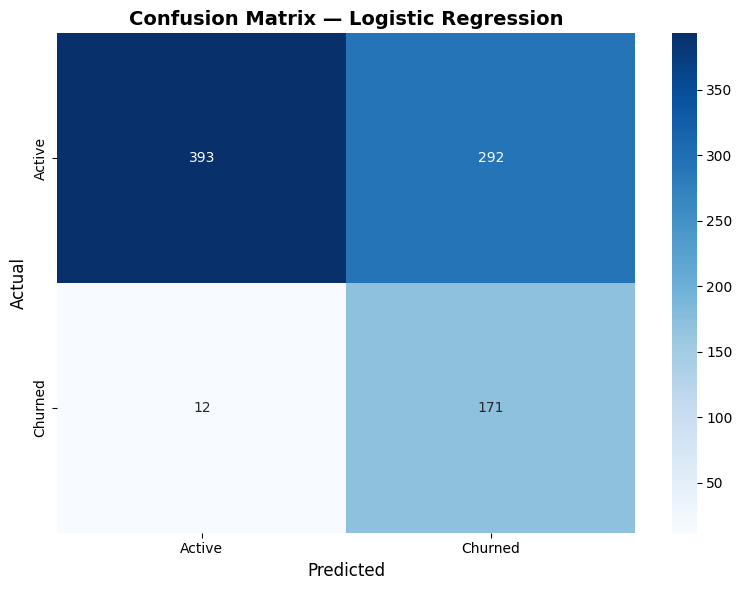

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8,6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=['Active','Churned'],
            yticklabels=['Active','Churned'])

plt.title('Confusion Matrix — Logistic Regression', 
          fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig("../images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Confusion Matrix

The confusion matrix shows how the model classified active and churned customers.

### Observation

- Correctly identified **393 active customers**.
- Correctly identified **171 churned customers**.
- Missed only **12 churned customers**.
- Incorrectly classified **292 active customers** as churned.

### Business Conclusion

The model successfully identifies most customers who are likely to churn. Although some active customers receive unnecessary retention offers, this cost is acceptable compared to the potential revenue lost from customers who actually churn. Therefore, the Balanced Logistic Regression model is well suited for customer retention.

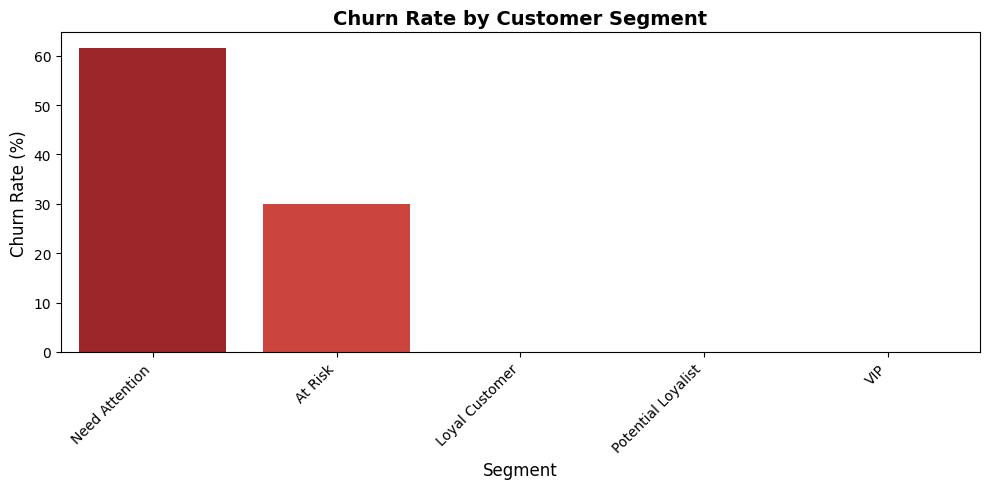

In [17]:
# Churn rate by segment
churn_by_segment = rfm.groupby('Segment')['Churn']\
                      .mean()\
                      .sort_values(ascending=False)\
                      .reset_index()

churn_by_segment['Churn'] = churn_by_segment['Churn'] * 100

plt.figure(figsize=(10,5))
sns.barplot(data=churn_by_segment,
            x='Segment',
            y='Churn',
            hue='Segment',
            palette='Reds_r',
            legend=False)

plt.title('Churn Rate by Customer Segment', 
          fontsize=14, fontweight='bold')
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../images/churn_by_segment.png", dpi=300, bbox_inches="tight")
plt.show()

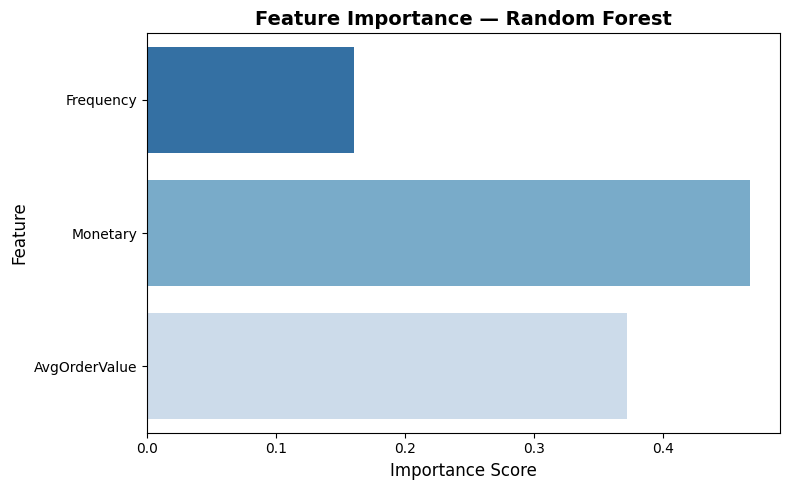

In [18]:
# Feature Importance from Random Forest
feature_names = ['Frequency', 'Monetary', 'AvgOrderValue']
importances = rf_model.feature_importances_

plt.figure(figsize=(8,5))
sns.barplot(x=importances, 
            y=feature_names,
            hue=feature_names,
            palette='Blues_r',
            legend=False)

plt.title('Feature Importance — Random Forest',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Insight 1 (from Confusion Matrix):
"The model successfully caught 171 out of 183 churned 
customers, missing only 12 — meaning 93% of at-risk 
customers can now be targeted for retention campaigns 
before they leave permanently."

Insight 2 (from Churn by Segment):
"Need Attention segment has the highest churn rate at 62%, 
suggesting these customers silently drift away without 
showing obvious warning signs — making them the highest 
priority for proactive retention strategies like 
personalized offers and re-engagement campaigns."

Insight 3 (from Churn by Segment):
"VIP and Loyal customers show near 0% churn, confirming 
that customers who buy frequently and spend consistently 
are the most stable revenue base — and should be protected 
through loyalty rewards and early access programs."

Insight 4 (from Feature Importance):
"Monetary value is the strongest predictor of churn at 
~45% importance, suggesting that how much a customer 
spends per visit reveals more about their likelihood 
of leaving than how often they visit — high one-time 
spenders who don't return are the biggest churn risk."

Insight 5 (combined):
"Despite having 860 churned customers, the business can 
proactively identify and save 171 of the highest-risk 
cases using this model — and even the 292 false positives 
represent an opportunity, as retention offers sent to 
active customers can still drive additional purchases 
and strengthen long-term loyalty."

Recommendation 1:
WHO:    Need Attention Segment (62% churn rate — highest risk)
WHAT:   Launch an urgent, targeted retention campaign
WHY:    This segment has the highest churn rate in the entire 
        customer base. Since Monetary is the strongest churn 
        predictor, losing these customers directly impacts 
        revenue. Proactive intervention before they cross the 
        180-day threshold is critical.
HOW:    Personalized emails with high-value coupons, early 
        access to new products, tailored recommendations based 
        on past purchases, and loyalty reward points to 
        re-establish buying habits.

Recommendation 2:
WHO:    171 model-identified churned customers
WHAT:   Immediate win-back campaign targeting confirmed 
        high-risk customers
WHY:    These customers have already crossed the churn 
        threshold. Every day without action increases the 
        risk of permanent loss. Given that Monetary is the 
        top predictor, even recovering a fraction of these 
        customers represents significant revenue recovery.
HOW:    Personalized win-back emails with strong incentives 
        (exclusive discount vouchers, "We miss you" campaigns), 
        prioritizing customers with historically high monetary 
        value first.

Recommendation 3:
WHO:    292 false positive customers (active but flagged)
WHAT:   Low-cost proactive engagement campaign
WHY:    Although these customers are currently active, being 
        flagged suggests behavioral patterns similar to churned 
        customers. A low-cost campaign now prevents them from 
        becoming actual churned customers later — turning a 
        model limitation into a business opportunity.
HOW:    Light-touch engagement — discount vouchers, product 
        recommendations based on purchase history, reward 
        points — enough to reinforce buying habits without 
        significant marketing spend.